# Реализация кода из статьи Google [How Important Is a Neuron?](https://arxiv.org/abs/1805.12233), перенесенная на детектор

In [19]:
# %%
import gc
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


In [20]:
# %%
# Загрузка именно детектора
yolo = YOLO("yolo11s.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names
num_classes_global = len(class_names)

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

DetectionModel
num classes: 80
first 10 classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}


In [48]:
# %%
IMG_SIZE = 640
DEFAULT_LAYER_NAME = "model.22"  # при необходимости поменяешь на другой spatial layer

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.uint8)

    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray(img_np).resize((new_w, new_h), Image.Resampling.BICUBIC)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    meta = {
        "orig_hw": (h, w),
        "resized_hw": (new_h, new_w),
        "pad_top": top,
        "pad_left": left,
        "scale": scale,
        "img_size": img_size,
    }
    return x, canvas, meta

def black_baseline_like(x):
    return torch.zeros_like(x)

def clear_backend_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

print("default layer:", DEFAULT_LAYER_NAME)

default layer: model.22


In [41]:
# %%
def print_main_yolo_layers(model, sample_input, max_depth=2):
    """
    Печатает основные слои YOLO и shape их выходов на одном forward-pass.
    - depth=1: model.0, model.1, ...
    - depth=2: model.15.cv1, model.15.cv2, ...
    """
    module_outputs = {}
    handles = []

    def make_hook(name):
        def hook(module, inp, out):
            module_outputs[name] = out
        return hook

    try:
        for name, module in model.named_modules():
            if name == "":
                continue
            if not name.startswith("model."):
                continue

            depth = name.count(".")
            if depth <= max_depth:
                handles.append(module.register_forward_hook(make_hook(name)))

        with torch.no_grad():
            _ = model(sample_input)

        print("Main YOLO layers:\n")
        for name, module in model.named_modules():
            if name == "":
                continue
            if not name.startswith("model."):
                continue

            depth = name.count(".")
            if depth <= max_depth:
                out = module_outputs.get(name, None)
                if torch.is_tensor(out):
                    shape_str = str(tuple(out.shape))
                elif isinstance(out, (list, tuple)):
                    tensor_shapes = [tuple(x.shape) for x in out if torch.is_tensor(x)]
                    shape_str = str(tensor_shapes) if tensor_shapes else f"<{type(out).__name__}>"
                elif out is None:
                    shape_str = "<no output captured>"
                else:
                    shape_str = f"<{type(out).__name__}>"

                print(f"{name:25s} {type(module).__name__:12s} output={shape_str}")
    finally:
        for h in handles:
            h.remove()


sample_x, _, _ = load_image("data/person.png")
print_main_yolo_layers(model, sample_x, max_depth=1)

Main YOLO layers:

model.0                   Conv         output=(1, 32, 320, 320)
model.1                   Conv         output=(1, 64, 160, 160)
model.2                   C3k2         output=(1, 128, 160, 160)
model.3                   Conv         output=(1, 128, 80, 80)
model.4                   C3k2         output=(1, 256, 80, 80)
model.5                   Conv         output=(1, 256, 40, 40)
model.6                   C3k2         output=(1, 256, 40, 40)
model.7                   Conv         output=(1, 512, 20, 20)
model.8                   C3k2         output=(1, 512, 20, 20)
model.9                   SPPF         output=(1, 512, 20, 20)
model.10                  C2PSA        output=(1, 512, 20, 20)
model.11                  Upsample     output=(1, 512, 40, 40)
model.12                  Concat       output=(1, 768, 40, 40)
model.13                  C3k2         output=(1, 256, 40, 40)
model.14                  Upsample     output=(1, 256, 80, 80)
model.15                  Concat

In [33]:
# %%
# Вспомогательные функции для hooks и plotting

class LayerHook:
    def __init__(self, model, layer_name):
        self.layer_name = layer_name
        self.layer_store = {}
        modules = dict(model.named_modules())
        if layer_name not in modules:
            raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
        self.handle = modules[layer_name].register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.layer_store[self.layer_name] = out

    def clear(self):
        self.layer_store.clear()

    def get(self):
        return self.layer_store[self.layer_name]

    def remove(self):
        self.handle.remove()

def unwrap_tensor(output):
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")

def reduce_filter_scores(cond_tensor):
    if cond_tensor.ndim < 2:
        raise ValueError(
            f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(cond_tensor.shape)}"
        )

    per_sample = cond_tensor[0]
    if per_sample.ndim == 1:
        return per_sample

    reduce_dims = tuple(range(1, per_sample.ndim))
    return per_sample.sum(dim=reduce_dims)

def _normalize_map(arr):
    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    denom = arr.max()
    if denom > 0:
        arr = arr / denom
    return arr

def _resize_map_nearest(arr, out_hw):
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)
    return arr[row_idx][:, col_idx]

def plot_total_conductance_overlay(image_np, cond_tensor, title=None):
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Общий spatial plot пропущен: у слоя нет пространственных осей.")
        return

    total_map = np.abs(cond_np).sum(axis=0)
    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="jet", alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total conductance overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized |conductance|", rotation=90)
    plt.show()

def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Spatial overlays для отдельных фильтров пропущены: у слоя нет пространственных осей.")
        return

    top_n = min(top_n, len(top_idx))
    for rank, idx in enumerate(top_idx[:top_n].tolist(), start=1):
        fmap = np.abs(cond_np[idx])
        fmap = _normalize_map(fmap)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="jet", alpha=0.45, interpolation="nearest")
        plt.axis("off")
        plt.title(f"Filter {idx} conductance = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

In [34]:
# %%
def find_largest_prediction_tensor(output):
    tensors = []

    def _collect(obj):
        if torch.is_tensor(obj) and obj.is_floating_point():
            tensors.append(obj)
        elif isinstance(obj, (list, tuple)):
            for item in obj:
                _collect(item)
        elif isinstance(obj, dict):
            for item in obj.values():
                _collect(item)

    _collect(output)
    if not tensors:
        raise RuntimeError("Не удалось найти float tensor в output детектора.")

    # Предпочитаем тензоры, похожие на сырые предсказания detector head.
    candidates = []
    for t in tensors:
        shape = tuple(t.shape)
        ok = False

        # [B, Q, D] или [B, D, Q]
        if t.ndim == 3 and (shape[1] >= 4 + num_classes_global or shape[2] >= 4 + num_classes_global):
            ok = True

        # [B, D, H, W]
        if t.ndim == 4 and shape[1] >= 4 + num_classes_global:
            ok = True

        if ok:
            candidates.append(t)

    if candidates:
        candidates = sorted(candidates, key=lambda t: t.numel(), reverse=True)
        return candidates[0]

    tensors = sorted(tensors, key=lambda t: t.numel(), reverse=True)
    return tensors[0]


def normalize_prediction_tensor(pred, num_classes):
    # Приведение к [B, Q, D]
    #
    # Поддерживаем:
    # - [B, Q, D]
    # - [B, D, Q]
    # - [B, D, H, W] -> [B, H*W, D]
    # - [B, H, W, D] -> [B, H*W, D]
    shape = tuple(pred.shape)

    if pred.ndim == 3:
        if pred.shape[-1] >= (4 + num_classes):
            return pred
        if pred.shape[1] >= (4 + num_classes):
            return pred.transpose(1, 2)
        raise RuntimeError(f"Не удалось интерпретировать 3D prediction tensor shape={shape}")

    if pred.ndim == 4:
        # [B, D, H, W]
        if pred.shape[1] >= (4 + num_classes):
            b, d, h, w = pred.shape
            return pred.permute(0, 2, 3, 1).reshape(b, h * w, d)

        # [B, H, W, D]
        if pred.shape[-1] >= (4 + num_classes):
            b, h, w, d = pred.shape
            return pred.reshape(b, h * w, d)

        raise RuntimeError(f"Не удалось интерпретировать 4D prediction tensor shape={shape}")

    raise RuntimeError(f"Ожидался 3D или 4D tensor, получено shape={shape}")


def parse_detection_head(raw_output, num_classes):
    pred = find_largest_prediction_tensor(raw_output)
    pred = normalize_prediction_tensor(pred, num_classes=num_classes)

    if pred.shape[-1] < 4 + num_classes:
        raise RuntimeError(
            f"Последняя размерность слишком мала: ожидалось >= {4 + num_classes}, получено {pred.shape[-1]}"
        )

    boxes = pred[..., :4]                  # [B, Q, 4]
    cls_logits = pred[..., -num_classes:]  # [B, Q, C]

    return {
        "pred": pred,
        "boxes": boxes,
        "cls_logits": cls_logits,
    }

In [35]:
# %%
# Выбор target на конечном изображении.
#
# Мы фиксируем target по x = исходной картинке,
# а потом используем тот же target на всех x(α).

def pick_fixed_query_target(raw_output, num_classes):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]  # [Q, C]

    flat_idx = int(cls_logits.reshape(-1).argmax().item())
    q_idx = flat_idx // num_classes
    class_idx = flat_idx % num_classes
    score = float(cls_logits[q_idx, class_idx].item())

    return {
        "mode": "fixed_query",
        "query_index": q_idx,
        "class_index": class_idx,
        "score": score,
        "box_xywh": parsed["boxes"][0, q_idx].detach().cpu(),
    }

def xywh_to_xyxy(xywh):
    x, y, w, h = xywh
    x1 = x - w / 2.0
    y1 = y - h / 2.0
    x2 = x + w / 2.0
    y2 = y + h / 2.0
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def make_roi_mask_from_fixed_box(boxes_xywh, fixed_box_xywh, center_only=True):
    # boxes_xywh: [Q, 4]
    # fixed_box_xywh: [4]
    boxes = boxes_xywh.detach().cpu().numpy()
    fixed_xyxy = xywh_to_xyxy(np.asarray(fixed_box_xywh))

    if center_only:
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )
    else:
        # Можно заменить на IoU-based matching, но center-in-box проще и стабильнее
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )

    return torch.from_numpy(mask)

def pick_fixed_roi_target(raw_output, num_classes, min_queries=1):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]   # [Q, C]
    boxes = parsed["boxes"][0]             # [Q, 4]

    flat_idx = int(cls_logits.reshape(-1).argmax().item())
    best_q = flat_idx // num_classes
    class_idx = flat_idx % num_classes

    fixed_box = boxes[best_q].detach().cpu().numpy()
    roi_mask = make_roi_mask_from_fixed_box(boxes, fixed_box, center_only=True)

    if roi_mask.sum().item() < min_queries:
        roi_mask[best_q] = True

    pooled_score = float(torch.logsumexp(cls_logits[roi_mask, class_idx], dim=0).item())

    return {
        "mode": "fixed_roi_lse",
        "class_index": class_idx,
        "seed_query_index": best_q,
        "fixed_box_xywh": torch.tensor(fixed_box),
        "roi_mask": roi_mask.clone(),
        "score": pooled_score,
    }

In [36]:
# %%
# Scalar target F(x) для обоих режимов

def detection_scalar_target(raw_output, target_spec, num_classes):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]  # [Q, C]

    if target_spec["mode"] == "fixed_query":
        q = target_spec["query_index"]
        c = target_spec["class_index"]
        return cls_logits[q, c]

    if target_spec["mode"] == "fixed_roi_lse":
        c = target_spec["class_index"]
        roi_mask = target_spec["roi_mask"].to(cls_logits.device)
        selected = cls_logits[roi_mask, c]
        return torch.logsumexp(selected, dim=0)

    raise ValueError(f"Неизвестный mode: {target_spec['mode']}")

In [37]:
# %%
def compute_detector_conductance(
    model,
    hook,
    x,
    x0,
    target_spec,
    num_classes,
    n_steps=64,
    fd_eps=1e-3,
    clear_every=8,
):
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=x.device, dtype=x.dtype)
    step = 1.0 / n_steps

    cond_accum = None
    used_fallback = False

    for k in range(n_steps):
        alpha = (alphas[k] + alphas[k + 1]) / 2.0
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        raw_out, act = forward_with_layer(x_alpha)
        score = detection_scalar_target(raw_out, target_spec=target_spec, num_classes=num_classes)

        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        try:
            def act_only(inp):
                inp = inp.contiguous()
                _, a = forward_with_layer(inp)
                return a

            _, act_tangent = jvp(act_only, (x_alpha,), (delta_x,))

        except RuntimeError as e:
            if "view size is not compatible with input tensor's size and stride" not in str(e):
                raise

            used_fallback = True

            alpha_plus = min(float(alpha.item()) + fd_eps, 1.0)
            alpha_minus = max(float(alpha.item()) - fd_eps, 0.0)
            denom = alpha_plus - alpha_minus

            if denom == 0.0:
                raise RuntimeError("Не удалось построить finite-difference fallback для dy/dalpha.")

            with torch.no_grad():
                _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

            act_tangent = (act_plus - act_minus) / denom
            del act_plus, act_minus

        integrand = grad_y * act_tangent
        cond_accum = integrand.detach() if cond_accum is None else (cond_accum + integrand.detach())

        del x_alpha, raw_out, act, score, grad_y, act_tangent, integrand
        hook.clear()

        if (k + 1) % clear_every == 0:
            clear_backend_cache()

    cond = cond_accum * step
    clear_backend_cache()

    if used_fallback:
        print("Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.")

    return cond.detach()

In [38]:
# %%
# Полезная визуализация target box/ROI на картинке

def draw_box_on_image(image_np, box_xywh, title=None):
    img = image_np.copy()
    h, w = img.shape[:2]

    x, y, bw, bh = box_xywh
    x1 = int(round(x - bw / 2))
    y1 = int(round(y - bh / 2))
    x2 = int(round(x + bw / 2))
    y2 = int(round(y + bh / 2))

    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w - 1, x2))
    y2 = max(0, min(h - 1, y2))

    plt.figure(figsize=(6, 6))
    plt.imshow(img, interpolation="nearest")
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), max(1, x2 - x1), max(1, y2 - y1), fill=False, linewidth=2)
    )
    plt.axis("off")
    plt.title(title or "Target box")
    plt.show()

In [39]:
# %%
def run_detector_conductance(
    image_path,
    mode="fixed_query",
    layer_name=DEFAULT_LAYER_NAME,
    n_steps=64,
    top_n=5,
    fd_eps=1e-3,
    clear_every=8,
):
    if mode not in {"fixed_query", "fixed_roi_lse"}:
        raise ValueError(f"Неизвестный mode: {mode}")

    x, img_np, meta = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)

    try:
        def forward_with_layer(x_in):
            hook.clear()
            out = model(x_in)
            act = unwrap_tensor(hook.get())
            return out, act

        with torch.no_grad():
            raw_out, act = forward_with_layer(x)

            if mode == "fixed_query":
                target_spec = pick_fixed_query_target(raw_out, num_classes=len(class_names))

                q = target_spec["query_index"]
                c = target_spec["class_index"]
                target_class_name = class_names[c]
                target_score = target_spec["score"]
                target_box = target_spec["box_xywh"].numpy()

                extra_lines = [
                    ("mode", "fixed_query"),
                    ("target query index", q),
                    ("target class", f"{c} {target_class_name}"),
                    ("target raw score at x", target_score),
                ]

            else:
                target_spec = pick_fixed_roi_target(raw_out, num_classes=len(class_names))

                c = target_spec["class_index"]
                target_class_name = class_names[c]
                seed_q = target_spec["seed_query_index"]
                target_box = target_spec["fixed_box_xywh"].numpy()
                roi_count = int(target_spec["roi_mask"].sum().item())
                target_score = target_spec["score"]

                extra_lines = [
                    ("mode", "fixed_roi_lse"),
                    ("seed query index", seed_q),
                    ("target class", f"{c} {target_class_name}"),
                    ("ROI query count", roi_count),
                    ("target pooled score at x", target_score),
                ]

        cond_tensor = compute_detector_conductance(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_spec=target_spec,
            num_classes=len(class_names),
            n_steps=n_steps,
            fd_eps=fd_eps,
            clear_every=clear_every,
        )

        filter_scores = reduce_filter_scores(cond_tensor)
        layer_score = cond_tensor.sum()
        topk = min(10, filter_scores.numel())
        top_vals, top_idx = torch.topk(filter_scores.abs(), k=topk)

        with torch.no_grad():
            raw_x, _ = forward_with_layer(x)
            raw_x0, _ = forward_with_layer(x0)
            fx = float(detection_scalar_target(raw_x, target_spec, len(class_names)).item())
            fx0 = float(detection_scalar_target(raw_x0, target_spec, len(class_names)).item())
            abs_error = abs((fx - fx0) - float(layer_score.item()))

        print("image:", image_path)
        print("layer:", layer_name)
        for key, value in extra_lines:
            print(f"{key}: {value}")
        print("layer activation shape:", tuple(act.shape))
        print("cond tensor shape:", tuple(cond_tensor.shape))
        print("filter_scores shape:", tuple(filter_scores.shape))

        print("\ntop filters by |conductance|:")
        for rank, idx in enumerate(top_idx.tolist(), start=1):
            val = float(filter_scores[idx].item())
            print(f"{rank:2d}. filter {idx:4d}: {val:+.6f}")

        print("\nlayer conductance sum:", float(layer_score.item()))
        print("F(x)            =", fx)
        print("F(x0)           =", fx0)
        print("F(x) - F(x0)    =", fx - fx0)
        print("sum conductance =", float(layer_score.item()))
        print("abs error       =", abs_error)

        box_title = (
            f"Fixed-query target box, class={target_class_name}"
            if mode == "fixed_query"
            else f"Fixed ROI seed box, class={target_class_name}"
        )
        overlay_title = (
            f"Total conductance, layer={layer_name}, fixed-query, class={target_class_name}"
            if mode == "fixed_query"
            else f"Total conductance, layer={layer_name}, fixed-ROI-LSE, class={target_class_name}"
        )

        draw_box_on_image(img_np, target_box, title=box_title)
        plot_total_conductance_overlay(img_np, cond_tensor, title=overlay_title)
        plot_top_filter_overlays(img_np, cond_tensor, filter_scores, top_idx, top_n=top_n)

        return {
            "mode": mode,
            "image_path": image_path,
            "layer_name": layer_name,
            "target_spec": target_spec,
            "cond_tensor": cond_tensor,
            "filter_scores": filter_scores,
            "layer_score": layer_score,
            "top_idx": top_idx,
            "top_vals": top_vals,
            "fx": fx,
            "fx0": fx0,
            "abs_error": abs_error,
        }

    finally:
        hook.remove()
        clear_backend_cache()

image: data/person.png
layer: model.0
mode: fixed_query
target query index: 2383
target class: 0 person
target raw score at x: 1.585169792175293
layer activation shape: (1, 32, 320, 320)
cond tensor shape: (1, 32, 320, 320)
filter_scores shape: (32,)

top filters by |conductance|:
 1. filter    7: +0.660085
 2. filter   26: +0.642232
 3. filter   19: -0.390666
 4. filter   13: -0.219319
 5. filter   20: -0.208847
 6. filter   12: -0.140227
 7. filter   15: +0.131347
 8. filter    2: -0.105402
 9. filter    4: -0.101367
10. filter    1: +0.098243

layer conductance sum: 0.32025572657585144
F(x)            = 1.585169792175293
F(x0)           = -14.650899887084961
F(x) - F(x0)    = 16.236069679260254
sum conductance = 0.32025572657585144
abs error       = 15.915813952684402


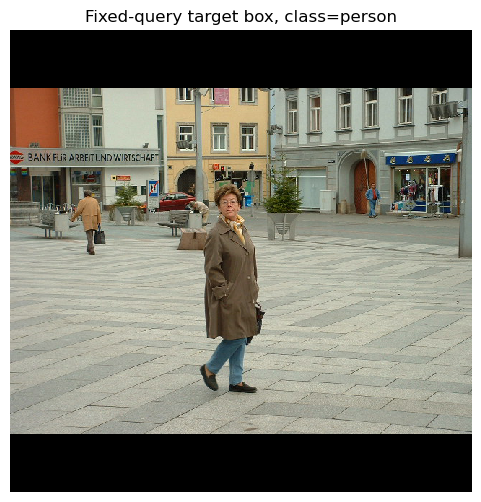

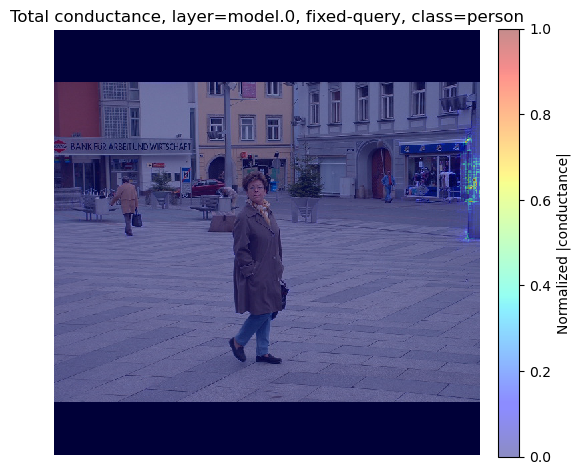

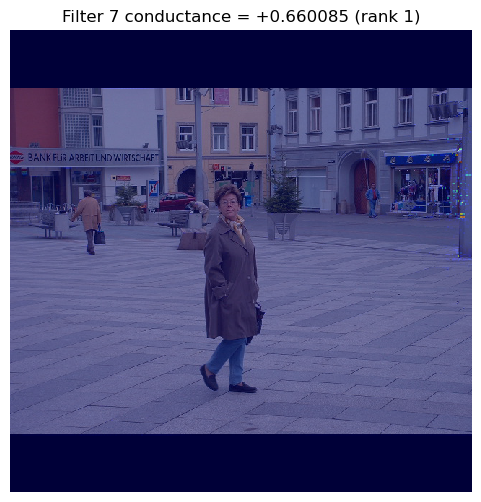

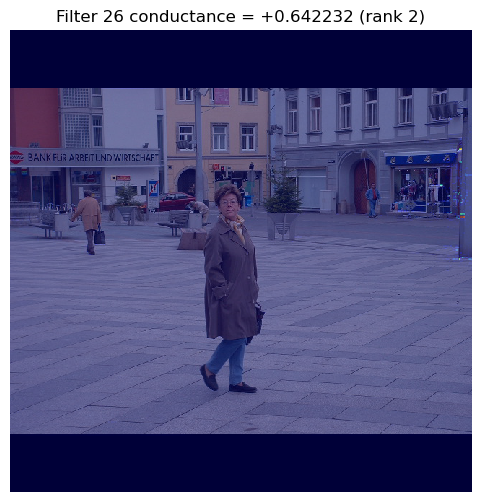

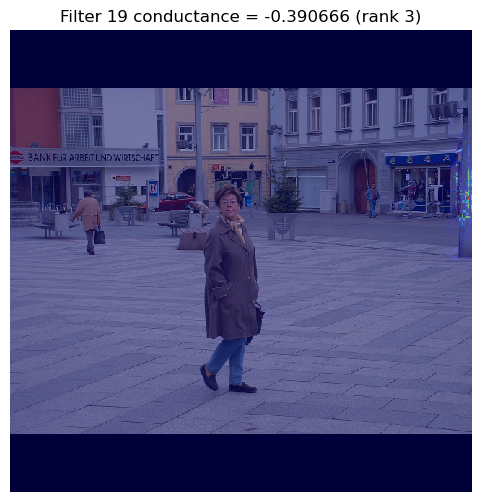

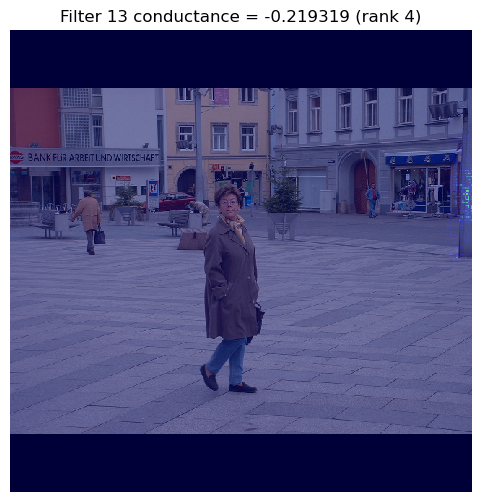

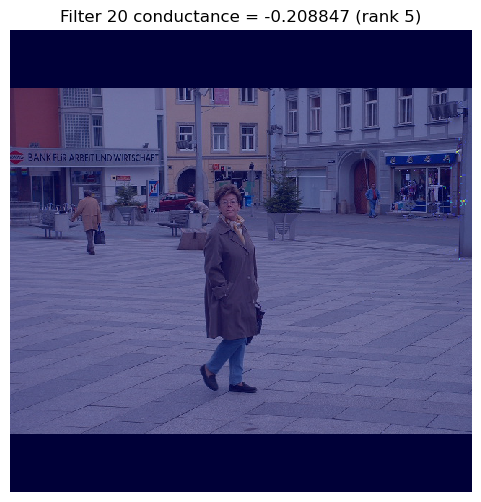

In [54]:
# %%
# Пример запуска: fixed-query
result_fixed_query = run_detector_conductance(
    image_path="data/person.png",
    mode="fixed_query",
    layer_name='model.0',
    n_steps=64,
    top_n=5,
)

# Пример запуска: fixed-ROI LogSumExp
# result_fixed_roi = run_detector_conductance(
#     image_path="data/person.jpg",
#     mode="fixed_roi_lse",
#     layer_name=DEFAULT_LAYER_NAME,
#     n_steps=64,
#     top_n=5,
# )

In [45]:
# %%
def print_detect_internals(model, sample_input, prefix="model.23", max_depth=5):
    """
    Печатает внутренние слои Detect и shape их выходов на одном forward-pass.
    Это нужно, чтобы выбрать слой внутри head, а не только перед головой.
    """
    module_outputs = {}
    handles = []

    def make_hook(name):
        def hook(module, inp, out):
            module_outputs[name] = out
        return hook

    try:
        for name, module in model.named_modules():
            if not name.startswith(prefix):
                continue
            if name.count(".") <= max_depth:
                handles.append(module.register_forward_hook(make_hook(name)))

        with torch.no_grad():
            _ = model(sample_input)

        print(f"Detect internals for prefix={prefix}:\n")
        for name, module in model.named_modules():
            if not name.startswith(prefix):
                continue
            if name.count(".") <= max_depth:
                out = module_outputs.get(name, None)
                if torch.is_tensor(out):
                    shape_str = str(tuple(out.shape))
                elif isinstance(out, (list, tuple)):
                    tensor_shapes = [tuple(x.shape) for x in out if torch.is_tensor(x)]
                    shape_str = str(tensor_shapes) if tensor_shapes else f"<{type(out).__name__}>"
                elif out is None:
                    shape_str = "<no output captured>"
                else:
                    shape_str = f"<{type(out).__name__}>"

                print(f"{name:35s} {type(module).__name__:12s} output={shape_str}")
    finally:
        for h in handles:
            h.remove()


print_detect_internals(model, sample_x, prefix="model.23", max_depth=5)

Detect internals for prefix=model.23:

model.23                            Detect       output=[(1, 84, 8400)]
model.23.cv2                        ModuleList   output=<no output captured>
model.23.cv2.0                      Sequential   output=(1, 64, 80, 80)
model.23.cv2.0.0                    Conv         output=(1, 64, 80, 80)
model.23.cv2.0.0.conv               Conv2d       output=(1, 64, 80, 80)
model.23.cv2.0.0.bn                 BatchNorm2d  output=(1, 64, 80, 80)
model.23.cv2.0.1                    Conv         output=(1, 64, 80, 80)
model.23.cv2.0.1.conv               Conv2d       output=(1, 64, 80, 80)
model.23.cv2.0.1.bn                 BatchNorm2d  output=(1, 64, 80, 80)
model.23.cv2.0.2                    Conv2d       output=(1, 64, 80, 80)
model.23.cv2.1                      Sequential   output=(1, 64, 40, 40)
model.23.cv2.1.0                    Conv         output=(1, 64, 40, 40)
model.23.cv2.1.0.conv               Conv2d       output=(1, 64, 40, 40)
model.23.cv2.1.0.bn 